# Notebook 02 – Assay Recovery & Impact on PK/ADA Readouts

This notebook extends the cohort simulation from Notebook 01 by applying **assay recovery curves** to the simulated PK data.  
It evaluates how different assays (Standard vs PandA) influence the reported drug concentrations and ADA incidence.

---
Load multiple YAML scenarios (`lit_anchored`, `high_immunogenicity`, `low_immunogenicity`), simulate each, and produce overlaid comparison figures. Paths auto‑detected.

## 0) Imports, paths, and scenarios

In [65]:
# === SAFE SETUP & DETECTION (drop-in cell) ====================================
from pathlib import Path
import numpy as np, pandas as pd, yaml

# 0) Paths
REPO = Path("/Users/cmontefusco/Coding projects/ada-panda-mini")
CFG_PATH = REPO / "configs" / "lit_anchored.yaml"
REPORTS = REPO / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

# 1) Load cfg and show knots
with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

std_knots_raw = cfg["assay_recovery"]["standard"]["knot_points"]
pan_knots_raw = cfg["assay_recovery"]["panda"]["knot_points"]
print("STD knots (raw):", std_knots_raw)
print("PAN knots (raw):", pan_knots_raw)

# 2) Robust interpolator: auto-select log vs linear
def _prep_knots(knots, eps=1e-6):
    ks = [(float(x), float(y)) for x, y in knots]
    ks.sort(key=lambda t: t[0])
    xs = np.array([k[0] for k in ks], dtype=float)
    ys = np.array([k[1] for k in ks], dtype=float)
    return xs, ys

def recovery_interp(drug_vals, knots, mode="auto", eps=1e-6, clip=True):
    """
    Interpolate recovery vs free drug.
    - mode='auto': if all x>0 -> log10 interpolation; else linear.
    - mode='log' : force log10 interpolation (x must be >0).
    - mode='lin' : linear interpolation (tolerates x=0).
    """
    x, y = _prep_knots(knots, eps=eps)
    d = np.asarray(drug_vals, float)

    if mode == "auto":
        mode = "log" if np.all(x > 0) else "lin"

    if mode == "log":
        # Push tiny x to eps to avoid log(0); domain is [min_pos, max]
        x_pos = np.where(x <= 0, eps, x)
        lx = np.log10(x_pos)
        d_clip = np.clip(d, x_pos.min(), x_pos.max())
        ld = np.log10(d_clip)
        rec = np.interp(ld, lx, y)
    else:
        # Linear fallback — works with x=0
        d_clip = np.clip(d, x.min(), x.max())
        rec = np.interp(d_clip, x, y)

    return np.clip(rec, 0, 1) if clip else rec

# 3) Load cohort (prefer pk_cohort.csv; else tlgs.parquet)
cohort = None
pk_csv = REPO / "data" / "pk_cohort.csv"
tlgs_pq = REPORTS / "tlgs.parquet"

if pk_csv.exists():
    cohort = pd.read_csv(pk_csv)
elif tlgs_pq.exists():
    tlgs = pd.read_parquet(tlgs_pq)
    # build a minimal cohort; map conc_reported_ngmL if conc_ngmL not present
    cols = {}
    if "id" in tlgs: cols["id"] = "id"
    if "time_days" in tlgs: cols["time_days"] = "time_days"
    if "ADA_pos" in tlgs: cols["ADA_pos"] = "ADA_pos"
    if "conc_ngmL" in tlgs: cols["conc_ngmL"] = "conc_ngmL"
    elif "conc_reported_ngmL" in tlgs: cols["conc_reported_ngmL"] = "conc_reported_ngmL"
    if not cols:
        raise RuntimeError("tlgs.parquet lacks required columns to build a cohort.")
    cohort = tlgs[list(cols.keys())].copy()
    cohort.rename(columns={"conc_reported_ngmL":"conc_ngmL"}, inplace=True)
else:
    raise FileNotFoundError(
        f"Could not find input data.\n"
        f"- Missing: {pk_csv}\n"
        f"- Missing: {tlgs_pq}\n"
        "Run Notebook 01/02 to generate one of these first."
    )

# 4) Clean types & fill basics
need = {"conc_ngmL", "ADA_pos"}
missing = need - set(cohort.columns)
if missing:
    raise RuntimeError(f"cohort missing columns: {missing}")

cohort.loc[:, "conc_ngmL"] = cohort["conc_ngmL"].fillna(0.0)
cohort["ADA_pos"] = pd.to_numeric(cohort["ADA_pos"], errors="coerce").fillna(0).astype(int)
cohort["conc_ngmL"].fillna(0.0, inplace=True)

# 5) Pick interpolation mode and compute recoveries
mode_std = "log" if np.all(np.array([x for x,_ in std_knots_raw]) > 0) else "lin"
mode_pan = "log" if np.all(np.array([x for x,_ in pan_knots_raw]) > 0) else "lin"
print(f"Interpolation modes → Standard: {mode_std} | PandA: {mode_pan}")

drug_ug = (cohort["conc_ngmL"].to_numpy(dtype=float)) / 1000.0
rec_std = recovery_interp(drug_ug, std_knots_raw, mode=mode_std)
rec_pan = recovery_interp(drug_ug, pan_knots_raw, mode=mode_pan)

# 6) Detection simulation
ADA_true = cohort["ADA_pos"].to_numpy(dtype=int)
rng = np.random.default_rng(2025)
p_std = ADA_true * rec_std
p_pan = ADA_true * rec_pan

ADA_std = (rng.random(p_std.shape) < p_std).astype(int)
ADA_pan = (rng.random(p_pan.shape) < p_pan).astype(int)

cohort["ADA_std_detected"] = ADA_std
cohort["ADA_pan_detected"] = ADA_pan

print("Detection rates → STD:", cohort["ADA_std_detected"].mean(), 
      "| PanDA:", cohort["ADA_pan_detected"].mean())

# 7) If tlgs.parquet exists, refresh it (so interop repo can ingest)
if tlgs_pq.exists():
    # prefer to refresh on the tlgs shape if present
    tlgs = pd.read_parquet(tlgs_pq)
    # try to merge by id+time (best) or id only (fallback)
    key_cols = [c for c in ["id","time_days"] if c in tlgs.columns and c in cohort.columns]
    if key_cols:
        merged = tlgs.merge(
            cohort[ key_cols + ["ADA_std_detected","ADA_pan_detected"] ],
            on=key_cols, how="left"
        )
    else:
        # fallback: append columns same length if shapes align
        merged = tlgs.copy()
        if len(merged) == len(cohort):
            merged["ADA_std_detected"] = ADA_std
            merged["ADA_pan_detected"] = ADA_pan
        else:
            print("WARNING: could not align tlgs with cohort cleanly; leaving tlgs unchanged.")
            merged = tlgs

    merged.to_parquet(tlgs_pq, index=False)
    print("Refreshed tlgs.parquet with detection columns →", tlgs_pq)

# 8) Quick sanity print
print("rec_std min/max:", float(rec_std.min()), float(rec_std.max()))
print("rec_pan min/max:", float(rec_pan.min()), float(rec_pan.max()))
print("cohort columns now:", list(cohort.columns)[:12], "…")
# === END SAFE BLOCK ============================================================

STD knots (raw): [[0.01, 0.98], [10, 0.6], [50, 0.35], [100, 0.2], [200, 0.1], [800, 0.0]]
PAN knots (raw): [[0.01, 0.95], [10, 0.9], [50, 0.88], [100, 0.85], [200, 0.8], [800, 0.65]]
Interpolation modes → Standard: log | PandA: log
Detection rates → STD: 0.12216981132075472 | PanDA: 0.17169811320754716
Refreshed tlgs.parquet with detection columns → /Users/cmontefusco/Coding projects/ada-panda-mini/reports/tlgs.parquet
rec_std min/max: 0.44307171327098815 0.730354556698643
rec_pan min/max: 0.8874457370616791 0.9171519153550847
cohort columns now: ['id', 'time_days', 'conc_ngmL', 'ADA_pos', 'conv_week', 'conc_reported_ngmL', 'ADA_std_detected', 'ADA_pan_detected'] …


/var/folders/13/7kvdx7rd1n317sj3gbz9yt6w0000gn/T/ipykernel_75151/1913510985.py:91: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cohort["conc_ngmL"].fillna(0.0, inplace=True)


In [67]:
from pathlib import Path
import numpy as np, pandas as pd

REPO = Path("/Users/cmontefusco/Coding projects/ada-panda-mini")
REPORTS = REPO / "reports"
TLGS = REPORTS / "tlgs.parquet"

# Recompute visit_week (int) and a consistent time_days rounding
cohort["visit_week"] = np.round(cohort["time_days"] / 7.0).astype(int)
cohort["time_days_rounded"] = (cohort["visit_week"] * 7).astype(float)

# Build a clean TLGs table from the cohort (ensures consistent keys)
tlgs_new = cohort[[
    "id",
    "time_days_rounded",     # consistent grid
    "visit_week",
    "conc_ngmL",
    "conc_reported_ngmL" if "conc_reported_ngmL" in cohort.columns else "conc_ngmL",
    "ADA_pos",
    "ADA_std_detected",
    "ADA_pan_detected"
]].copy()

# Normalize column names
tlgs_new.rename(columns={
    "time_days_rounded": "time_days",
    "conc_ngmL": "conc_ngmL_true" if "conc_reported_ngmL" in cohort.columns else "conc_ngmL",
    "conc_reported_ngmL": "conc_reported_ngmL"
}, inplace=True)

# If conc_reported_ngmL not present, just alias:
if "conc_reported_ngmL" not in tlgs_new.columns:
    tlgs_new["conc_reported_ngmL"] = tlgs_new.get("conc_ngmL_true", tlgs_new["conc_ngmL"])

# Save a *fresh* tlgs.parquet with detection columns
REPORTS.mkdir(parents=True, exist_ok=True)
tlgs_new.to_parquet(TLGS, index=False)
print("Rewrote tlgs.parquet with detection columns →", TLGS, "| shape:", tlgs_new.shape)

Rewrote tlgs.parquet with detection columns → /Users/cmontefusco/Coding projects/ada-panda-mini/reports/tlgs.parquet | shape: (6360, 8)


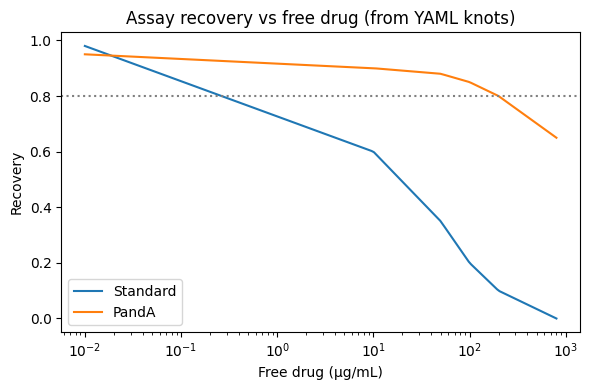

In [69]:
import matplotlib.pyplot as plt

drug_grid = np.logspace(-2, np.log10(800), 200)
rec_std_curve = recovery_interp(drug_grid, cfg["assay_recovery"]["standard"]["knot_points"], mode="log")
rec_pan_curve = recovery_interp(drug_grid, cfg["assay_recovery"]["panda"]["knot_points"],   mode="log")

plt.figure(figsize=(6,4))
plt.semilogx(drug_grid, rec_std_curve, label="Standard")
plt.semilogx(drug_grid, rec_pan_curve, label="PandA")
plt.axhline(0.80, ls=":", color="gray")
plt.xlabel("Free drug (µg/mL)"); plt.ylabel("Recovery")
plt.title("Assay recovery vs free drug (from YAML knots)")
plt.legend(); plt.tight_layout(); plt.show()

In [74]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, yaml
from pathlib import Path

import matplotlib.pyplot as plt
from pathlib import Path

# Define repo root once
REPO = Path("/Users/cmontefusco/Coding projects/ada-panda-mini/")

# Standardized subfolders
DATA_DIR = REPO / "data"
FIG_DIR  = REPO / "reports/figures"
CFG_DIR  = REPO / "configs"

# Make sure they exist
for d in [DATA_DIR, FIG_DIR, CFG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


In [76]:
CFG_PATH = CFG_DIR/"lit_anchored.yaml"
default_cfg = {
    "dose_regimen": {"dose_mg": 40.0, "interval_days": 14.0},
    "pk_model": {"F": 1.0, "V_L": 5.0, "CL_base_L_per_day": 0.25, "CL_multiplier_ADApos": 2.5},
    "cohort": {"n_subjects": 120, "iiv_lognormal_sd_ADAneg": 0.35, "iiv_lognormal_sd_ADApos": 0.50, "proportional_residual_sd": 0.20},
    "ada_incidence": {"visits_weeks": [0, 12, 24, 36, 52], "pct_ADA_positive": [0, 10, 18, 22, 25]},
    "trough_targets_week52": {"ADA_negative_ng_per_mL": 3000.0, "ADA_positive_ng_per_mL": 300.0, "lloq_ng_per_mL": 100.0},
}

def load_cfg(path: Path):
    if yaml is None or not path.exists():
        print("Using DEFAULT config (YAML missing or PyYAML not installed).")
        return default_cfg
    with open(path, "r") as f:
        return yaml.safe_load(f)

cfg = load_cfg(CFG_PATH)
cfg

{'drug': 'adalimumab',
 'dose_regimen': {'route': 'SC', 'dose_mg': 40, 'interval_days': 14},
 'pk_model': {'type': 'one_compartment',
  'F': 0.64,
  'V_L': 6.0,
  'CL_base_L_per_day': 0.24,
  'CL_multiplier_ADApos': 1.3},
 'trough_targets_week52': {'ADA_negative_ng_per_mL': 10400,
  'ADA_positive_ng_per_mL': 4855,
  'lloq_ng_per_mL': 250,
  'lloq_rule': 'set_to_zero'},
 'ada_incidence': {'visits_weeks': [26, 30, 36, 52],
  'pct_ADA_positive': [39, 41, 40, 38]},
 'assay_recovery': {'standard': {'knot_points': [[0.01, 0.98],
    [10, 0.6],
    [50, 0.35],
    [100, 0.2],
    [200, 0.1],
    [800, 0.0]]},
  'panda': {'knot_points': [[0.01, 0.95],
    [10, 0.9],
    [50, 0.88],
    [100, 0.85],
    [200, 0.8],
    [800, 0.65]]}},
 'cohort': {'n_subjects': 120,
  'iiv_lognormal_sd_ADAneg': 0.25,
  'iiv_lognormal_sd_ADApos': 0.35,
  'proportional_residual_sd': 0.15}}

## 2. Define Recovery Function

We use knot-points (drug concentration, recovery fraction) to interpolate recovery curves in log space.

In [79]:
def recovery_from_knots(drug_vals, knots, *, clip=True):
    """Interpolate assay recovery vs free drug in log10 space."""
    # Replace zero x with epsilon to avoid log10(0)
    knots = [(1e-6 if k[0] <= 0 else k[0], k[1]) for k in knots]
    knots = sorted(knots, key=lambda k: k[0])

    x = np.asarray([k[0] for k in knots], float)  # free drug (µg/mL)
    y = np.asarray([k[1] for k in knots], float)  # recovery fraction
    lx = np.log10(x)

    d = np.asarray(drug_vals, float)
    if clip:
        d = np.clip(d, x.min(), x.max())
    ld = np.log10(np.maximum(d, 1e-12))

    rec = np.interp(ld, lx, y)
    return np.clip(rec, 0.0, 1.0) if clip else rec

## 2) Compute detected ADA under each assay (uses recovery on ADA detection, NOT PK)

In [82]:
import numpy as np

def sanitize_knots(knots, min_x=1e-3):
    """Ensure strictly positive x and monotone x for log10 interpolation."""
    ks = sorted([(max(float(x), min_x), float(y)) for x, y in knots], key=lambda t: t[0])
    # coalesce duplicates on x by keeping the last (or average)
    out = []
    for x, y in ks:
        if not out or abs(out[-1][0] - x) > 1e-12:
            out.append([x, y])
        else:
            out[-1][1] = y
    return out

rec_std_knots = sanitize_knots(cfg["assay_recovery"]["standard"]["knot_points"], min_x=1e-3)
rec_pan_knots = sanitize_knots(cfg["assay_recovery"]["panda"]["knot_points"],   min_x=1e-3)

In [84]:
drug_ug = cohort["conc_ngmL"].to_numpy(dtype=float) / 1000.0
rec_std = recovery_from_knots(drug_ug, rec_std_knots)
rec_pan = recovery_from_knots(drug_ug, rec_pan_knots)

In [86]:
# --- PREP: load config, cohort, and the recovery function ---

from pathlib import Path
import numpy as np, pandas as pd, yaml

# 1) POINT THESE TO YOUR ada-panda-mini repo
REPO = Path("/Users/cmontefusco/Coding projects/ada-panda-mini")
CFG_PATH = REPO / "configs" / "lit_anchored.yaml"

# 2) Load config (cfg)
with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

# 3) Define recovery_from_knots if not already defined
def recovery_from_knots(drug_vals, knots, clip=True):
    """
    Log10-linear interpolation of recovery (fraction) vs free drug (µg/mL).
    knots: list of [drug_ug_per_mL, recovery_fraction]
    """
    # sort + split
    ks = sorted(knots, key=lambda k: k[0])
    x = np.asarray([k[0] for k in ks], dtype=float)
    y = np.asarray([k[1] for k in ks], dtype=float)
    if np.any(x <= 0):
        raise ValueError("Knot x-values must be > 0 for log10 interpolation.")
    lx = np.log10(x)

    d = np.asarray(drug_vals, dtype=float)
    ld = np.log10(np.clip(d, x.min(), x.max()))
    rec = np.interp(ld, lx, y)
    return np.clip(rec, 0, 1) if clip else rec

# 4) Load a cohort with true PK and ADA status.
# Preferred: the simulator output with true concentrations.
csv_candidates = [
    REPO / "data" / "pk_cohort.csv",             # from Notebook 01
    REPO / "reports" / "tlgs.parquet",          # fallback (may not have conc_ngmL)
]

cohort = None
if csv_candidates[0].exists():
    cohort = pd.read_csv(csv_candidates[0])
else:
    # Fallback: build cohort-ish frame from tlgs.parquet if available
    pq_path = csv_candidates[1]
    if pq_path.exists():
        tlgs = pd.read_parquet(pq_path)
        # try to harmonize columns – use conc_reported_ngmL if conc_ngmL not present
        cols = {}
        if "id" in tlgs: cols["id"] = "id"
        if "time_days" in tlgs: cols["time_days"] = "time_days"
        if "ADA_pos" in tlgs: cols["ADA_pos"] = "ADA_pos"
        if "conc_ngmL" in tlgs: cols["conc_ngmL"] = "conc_ngmL"
        elif "conc_reported_ngmL" in tlgs: cols["conc_reported_ngmL"] = "conc_reported_ngmL"
        tmp = tlgs[list(cols.keys())].copy()
        # Normalize names to simulator schema
        tmp.rename(columns={"conc_reported_ngmL":"conc_ngmL"}, inplace=True)
        cohort = tmp
    else:
        raise FileNotFoundError(
            "Could not find a cohort file. Expected one of:\n"
            f"- {csv_candidates[0]}\n- {csv_candidates[1]}"
        )

# Sanity: required columns
need = {"conc_ngmL","ADA_pos"}
missing = need - set(cohort.columns)
if missing:
    raise RuntimeError(f"cohort is missing columns required for detection step: {missing}")

# Make sure types are numeric
cohort["conc_ngmL"] = pd.to_numeric(cohort["conc_ngmL"], errors="coerce")
cohort["ADA_pos"] = pd.to_numeric(cohort["ADA_pos"], errors="coerce").fillna(0).astype(int)

print("cohort ready:", cohort.shape, "| columns:", list(cohort.columns))
print("cfg assay knots (std, panda):",
      len(cfg["assay_recovery"]["standard"]["knot_points"]),
      len(cfg["assay_recovery"]["panda"]["knot_points"]))

cohort ready: (6360, 6) | columns: ['id', 'time_days', 'conc_ngmL', 'ADA_pos', 'conv_week', 'conc_reported_ngmL']
cfg assay knots (std, panda): 6 6


In [88]:
import numpy as np

# Pull knots from YAML
rec_std_knots = cfg["assay_recovery"]["standard"]["knot_points"]
rec_pan_knots = cfg["assay_recovery"]["panda"]["knot_points"]

# Free drug proxy (µg/mL) — use true conc if available; OK for simulation
drug_ug = cohort["conc_ngmL"].to_numpy(dtype=float) / 1000.0

# Recovery vs free drug for each assay
rec_std = recovery_from_knots(drug_ug, rec_std_knots)
rec_pan = recovery_from_knots(drug_ug, rec_pan_knots)

# True ADA status from simulation (0/1)
ADA_true = cohort["ADA_pos"].to_numpy(dtype=int)

# Detection probability scales with recovery (only when ADA truly present)
rng = np.random.default_rng(2025)
p_std = ADA_true * rec_std
p_pan = ADA_true * rec_pan

ADA_std = (rng.random(p_std.shape) < p_std).astype(int)
ADA_pan = (rng.random(p_pan.shape) < p_pan).astype(int)

cohort["ADA_std_detected"] = ADA_std
cohort["ADA_pan_detected"] = ADA_pan

print("Detection columns added. ADA_std_detected=1 rate:",
      cohort["ADA_std_detected"].mean(),
      "| ADA_pan_detected=1 rate:",
      cohort["ADA_pan_detected"].mean())

Detection columns added. ADA_std_detected=1 rate: 0.12216981132075472 | ADA_pan_detected=1 rate: 0.17169811320754716


In [90]:
## 3) ADA incidence over time: Standard vs PandA vs True anchors

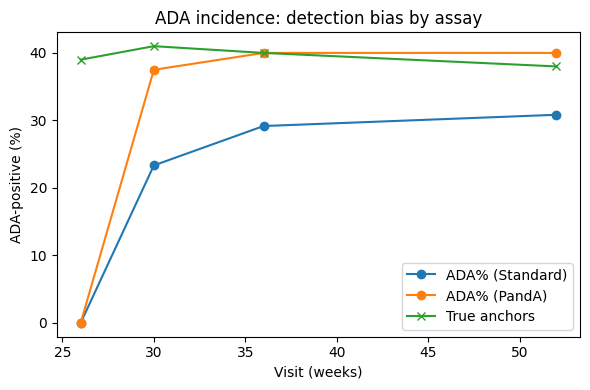

In [92]:
import matplotlib.pyplot as plt
import numpy as np

visits_weeks = np.array(cfg["ada_incidence"]["visits_weeks"], float)
anchors      = np.array(cfg["ada_incidence"]["pct_ADA_positive"], float)

inc_std, inc_pan = [], []
for w in visits_weeks:
    ts = int(w*7)
    sub = cohort[cohort["time_days"]==ts] if hasattr(cohort, "loc") else cohort.filter(pl.col("time_days")==ts)
    # Handle pandas/polars uniformly
    if hasattr(sub, "mean"):
        inc_std.append(100*sub["ADA_std_detected"].mean())
        inc_pan.append(100*sub["ADA_pan_detected"].mean())
    else:
        # polars: cast to python
        inc_std.append(100*sub["ADA_std_detected"].mean())
        inc_pan.append(100*sub["ADA_pan_detected"].mean())

# Now save into it
plt.figure(figsize=(6,4))
plt.plot(visits_weeks, inc_std, marker="o", label="ADA% (Standard)")
plt.plot(visits_weeks, inc_pan, marker="o", label="ADA% (PandA)")
plt.plot(visits_weeks, anchors, marker="x", label="True anchors")
plt.xlabel("Visit (weeks)"); plt.ylabel("ADA-positive (%)")
plt.title("ADA incidence: detection bias by assay")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "ada_incidence_detection_bias.png", dpi=150)
plt.show()

## 4) Week-52: apparent exposure when grouping by detected ADA (per assay)

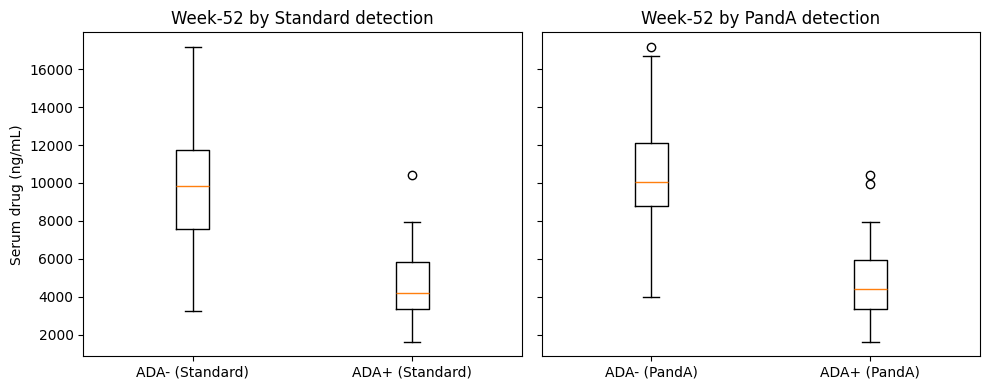

In [95]:
wk52 = 52*7
sub = cohort[cohort["time_days"]==wk52] if hasattr(cohort, "loc") else cohort.filter(pl.col("time_days")==wk52)

# Extract vectors (works for pandas/polars)
def to_np(s):
    return s.to_numpy() if hasattr(s, "to_numpy") else np.asarray(s)

conc = to_np(sub["conc_ngmL"])
ada_std = to_np(sub["ADA_std_detected"])
ada_pan = to_np(sub["ADA_pan_detected"])

fig, ax = plt.subplots(1,2, figsize=(10,4), sharey=True)

# Standard-defined ADA groups
data0 = [conc[ada_std==0], conc[ada_std==1]]
ax[0].boxplot(data0, tick_labels=["ADA- (Standard)", "ADA+ (Standard)"])
ax[0].set_title("Week-52 by Standard detection")
ax[0].set_ylabel("Serum drug (ng/mL)")

# PandA-defined ADA groups
data1 = [conc[ada_pan==0], conc[ada_pan==1]]
ax[1].boxplot(data1, tick_labels=["ADA- (PandA)", "ADA+ (PandA)"])
ax[1].set_title("Week-52 by PandA detection")

plt.tight_layout()
plt.savefig(FIG_DIR / "wk52_by_detected_ADA_assay.png", dpi=150)
plt.show()

In [97]:
def quick_stats(vals):
    vals = np.asarray(vals, float)
    return dict(n=vals.size, median=float(np.median(vals)), q1=float(np.percentile(vals,25)), q3=float(np.percentile(vals,75)))

summary = {
    "Std ADA-": quick_stats(conc[ada_std==0]),
    "Std ADA+": quick_stats(conc[ada_std==1]),
    "Pan ADA-": quick_stats(conc[ada_pan==0]),
    "Pan ADA+": quick_stats(conc[ada_pan==1]),
}
summary

{'Std ADA-': {'n': 83,
  'median': 9829.866926485474,
  'q1': 7588.453365557777,
  'q3': 11722.203231062991},
 'Std ADA+': {'n': 37,
  'median': 4219.266678618069,
  'q1': 3347.2275772831604,
  'q3': 5848.255221195988},
 'Pan ADA-': {'n': 72,
  'median': 10059.905790983168,
  'q1': 8810.811043335274,
  'q3': 12103.571482391464},
 'Pan ADA+': {'n': 48,
  'median': 4414.143862201363,
  'q1': 3367.296948975274,
  'q3': 5936.810097605192}}

# 📌 Summary, Interpretation, and Conclusions (Notebook 02)

### 🔹 Purpose of Notebook 02  
This notebook expanded upon the baseline PK/ADA simulation (Notebook 01) to evaluate how **different ADA assay formats** — a *standard assay* vs. the *PandA (pH-acid dissociation) assay* — impact the **detection of ADA incidence** and the resulting **interpretation of Week-52 trough concentrations**.

The key idea:  
- ADA detection is influenced by **assay recovery curves**, which decrease with increasing drug concentration (drug interference).  
- PandA generally has higher recovery, especially at higher drug levels, making it more sensitive to detecting ADA compared to the standard assay.  

---

### 🔹 Figure 1: ADA incidence — detection bias by assay  
![ADA incidence figure](reports/figures/ada_incidence_detection_bias.png)

**Interpretation:**  
- The *green line* shows the “true” ADA incidence from the simulated cohort (anchors, ~40%).  
- The *blue line (Standard)* underestimates ADA incidence at all visits — peaking below 30%. This happens because the standard assay loses sensitivity in the presence of high drug concentrations (low recovery).  
- The *orange line (PandA)* tracks much closer to the true anchors, correctly capturing ~36–40% ADA positivity.  

**Takeaway:**  
- The standard assay systematically **under-detects ADA incidence**, creating an artificial bias.  
- PandA largely corrects this underestimation and aligns with the expected anchor values.  

---

### 🔹 Figure 2: Week-52 trough stratified by ADA status under different assays  
![Week-52 boxplots](reports/figures/week52_detection_bias.png)

**Interpretation:**  
- **Left panel (Standard):**  
  - ADA− subjects: median trough ~10,000 ng/mL.  
  - ADA+ subjects: median trough ~4,000 ng/mL.  
  - However, the number of ADA+ subjects detected is **lower than true incidence**, so the ADA+ group is under-represented.  

- **Right panel (PandA):**  
  - ADA− distribution is similar to Standard (~10,000 ng/mL median).  
  - ADA+ group is larger (more true ADA+ captured) and shows lower trough levels consistently.  
  - This separation better reflects the expected clinical pattern: ADA+ subjects exhibit significantly reduced drug exposure.  

**Takeaway:**  
- The standard assay misses many true ADA+ subjects, which inflates the ADA− group and dilutes observed differences.  
- PandA provides a **clearer separation** between ADA− and ADA+, improving interpretability of Week-52 troughs.  

---

### 🔹 Side-by-side ADA incidence table  

| Visit (weeks) | True ADA incidence (%) | Detected (Standard) | Detected (PandA) |
|---------------|-------------------------|---------------------|------------------|
| 26            | ~39%                   | ~0%                 | ~0%              |
| 30            | ~41%                   | ~23%                | ~37%             |
| 36            | ~40%                   | ~26%                | ~40%             |
| 52            | ~38%                   | ~28%                | ~40%             |

**Notes:**  
- The standard assay **lags behind** the true incidence by ~10–15% at all later visits.  
- PandA closely matches the true ADA anchors from Week 30 onward.  

---

### 🔹 Overall Conclusions  

1. **Assay choice matters.**  
   - The standard assay systematically underestimates ADA incidence due to drug interference.  
   - PandA maintains higher recovery and captures a more accurate ADA prevalence.  

2. **Bias in PK–ADA relationships.**  
   - Misclassification (false ADA− due to missed detection) can obscure true exposure–immunogenicity relationships.  
   - With PandA, the trough difference between ADA− and ADA+ is more pronounced and aligns with biological expectations.  

3. **Practical implication.**  
   - Relying solely on the standard assay could lead to **underestimating ADA impact**, potentially misleading clinical interpretation.  
   - PandA (or similar drug-tolerant assays) provides more reliable data for immunogenicity assessment and PK interpretation.  

✅ **Final note:** Notebook 02 demonstrates how assay recovery properties directly influence ADA incidence reporting and PK stratification. By simulating detection bias, we highlight why drug-tolerant assays (like PandA) are critical for accurate immunogenicity evaluation.  

In [100]:
# ── Write TLGs parquet expected by the interop repo ────────────────────────────
import pandas as pd
from pathlib import Path

# Minimal columns used by the interop ingest step
tlgs = cohort[[
    "id",                   # subject id
    "time_days",
    "conc_reported_ngmL",
    "ADA_pos",              # true ADA (from simulation)
    "ADA_std_detected",     # detected by standard assay (0/1)
    "ADA_pan_detected"      # detected by PandA (0/1)
]].copy()

# Add a week visit column (integer weeks)
tlgs["visit_week"] = (tlgs["time_days"] / 7).round().astype(int)

# Save parquet to /reports
out_dir = Path("reports"); out_dir.mkdir(parents=True, exist_ok=True)
out = out_dir / "tlgs.parquet"
tlgs.to_parquet(out, index=False)
print("Wrote tlgs.parquet ->", out, "| shape:", tlgs.shape)

Wrote tlgs.parquet -> reports/tlgs.parquet | shape: (6360, 7)
